# Pressure–Flow Rate Calibration Curve
**Data:** Fluorescent bead tracking (TrackMate/Fiji) at controlled pressures  
**Experiment:** Data on beads – 10/12/25  
**Two technical repeats, combined for final calibration**

## 1 · Imports and settings

In [ ]:
import glob
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from scipy.stats import wilcoxon, ttest_rel
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')

# ── Shared colour palette ──────────────────────────────────────────────────
BLUE   = "#003366"   # repeat 1
ORANGE = "#cc6600"   # repeat 2
GRAY   = "#bbbbbb"   # individual track scatter

# Pressures to include in the calibration (present in both repeats)
CALIB_PRESSURES = [10, 40, 75, 100]


Mounted at /content/drive


## 2 · Load raw data

Each TrackMate output file corresponds to one applied pressure.  
Files are read from Google Drive; pressure is extracted from the filename.  
Only the four pressures present in **both** repeats are retained for analysis.

In [ ]:
def load_repeat(folder_pattern, calib_pressures=CALIB_PRESSURES):
    """
    Load all TrackMate .xlsx files matching folder_pattern.
    Returns a DataFrame with a 'Pressure_mbar' column prepended,
    restricted to calib_pressures.
    """
    file_list = glob.glob(folder_pattern)

    # Exclude any previously saved combined files
    file_list = [f for f in file_list if "combined" not in f.lower()]

    print("Files found:")
    for f in file_list:
        print(" -", f)

    def extract_pressure(filename):
        match = re.search(r'(\d+)\s*mbar', filename, re.IGNORECASE)
        return int(match.group(1)) if match else None

    dfs = []
    for file in file_list:
        pressure = extract_pressure(file)
        if pressure not in calib_pressures:
            print(f"   [skipped – {pressure} mbar not in calibration set]")
            continue
        df = pd.read_excel(file, header=1, skiprows=[2, 3], engine='openpyxl')
        df.insert(0, "Pressure_mbar", pressure)
        dfs.append(df)

    combined = pd.concat(dfs, ignore_index=True)
    print(f"\nLoaded {len(combined)} tracks across pressures: "
          f"{sorted(combined['Pressure_mbar'].unique())}\n")
    return combined


In [ ]:
folder_rep1 = "/content/drive/MyDrive/Colab Notebooks/MEP/results_beads_251210/repeat_1/*.xlsx"
folder_rep2 = "/content/drive/MyDrive/Colab Notebooks/MEP/results_beads_251210/repeat_2/*.xlsx"

raw_1 = load_repeat(folder_rep1)
raw_2 = load_repeat(folder_rep2)


Files found:
 - /content/drive/MyDrive/Colab Notebooks/MEP/results_beads_bert_251210/repeat_1/Resultof_final_tracks_10mbar_rep1.xlsx
 - /content/drive/MyDrive/Colab Notebooks/MEP/results_beads_bert_251210/repeat_1/Resultof_final_tracks_40mbar_rep1.xlsx
 - /content/drive/MyDrive/Colab Notebooks/MEP/results_beads_bert_251210/repeat_1/Resultof_final_tracks_75mbar_rep1.xlsx
 - /content/drive/MyDrive/Colab Notebooks/MEP/results_beads_bert_251210/repeat_1/Resultof_final_tracks_100mbar__row1_rep1.xlsx

Loaded 188 tracks across pressures: [np.int64(10), np.int64(40), np.int64(75), np.int64(100)]

Files found:
 - /content/drive/MyDrive/Colab Notebooks/MEP/results_beads_bert_251210/repeat_2/Resultof_final_tracks_75mbar.xlsx
 - /content/drive/MyDrive/Colab Notebooks/MEP/results_beads_bert_251210/repeat_2/Resultof_final_tracks_10mbar.xlsx
 - /content/drive/MyDrive/Colab Notebooks/MEP/results_beads_bert_251210/repeat_2/Resultof_final_tracks_40mbar.xlsx
 - /content/drive/MyDrive/Colab Notebooks/MEP/

## 3 · Distribution of bead velocities (unfiltered)

Before applying any filtering, we inspect the full velocity distributions per pressure and per repeat.

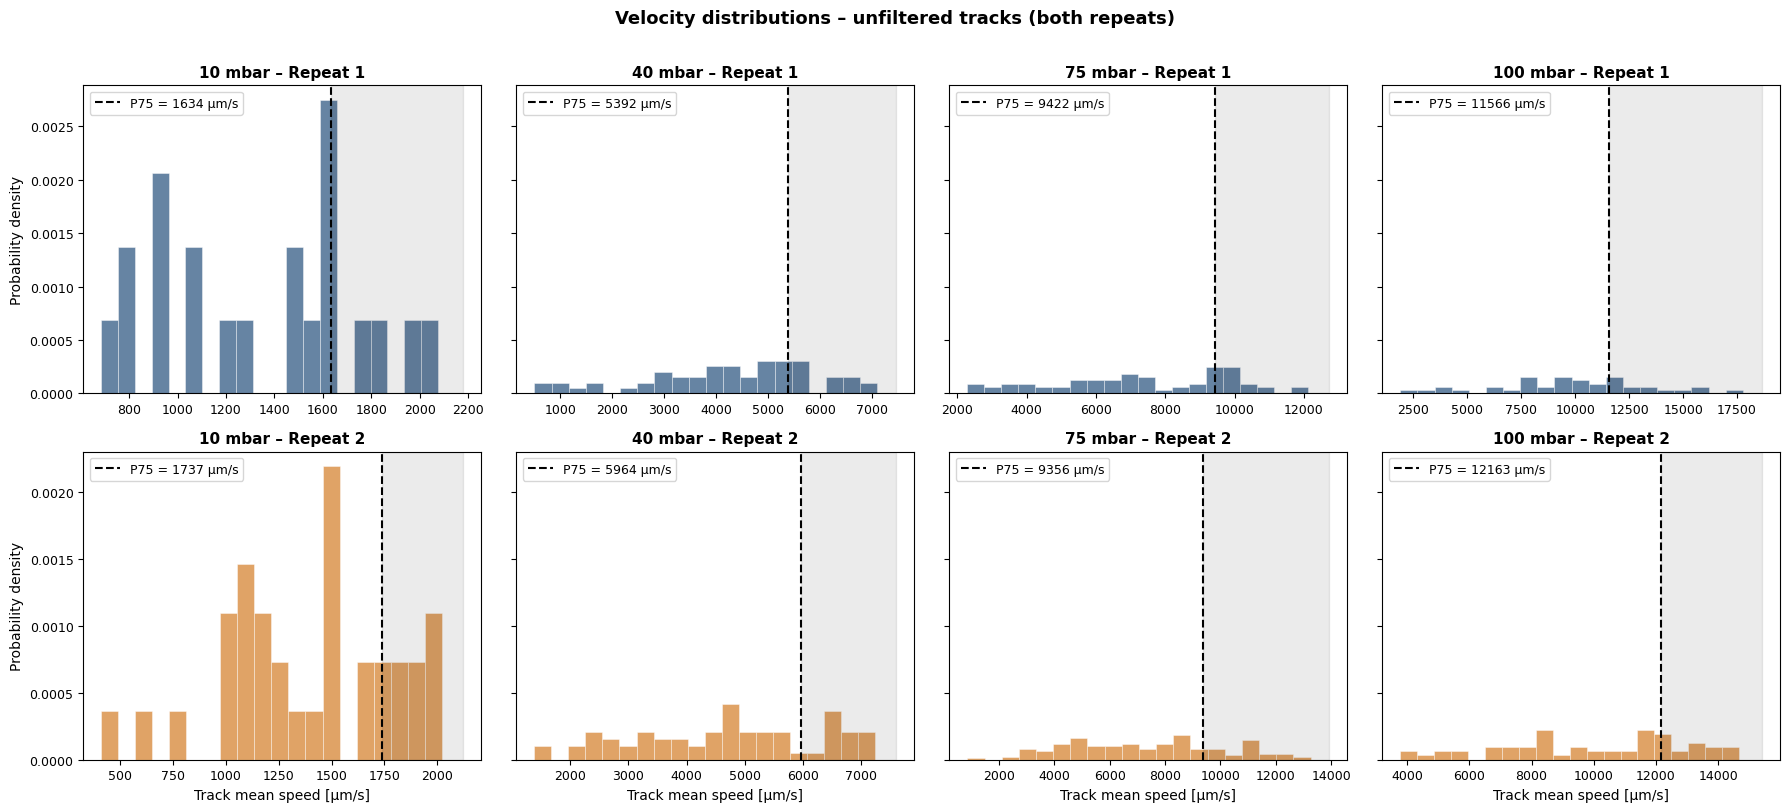

In [ ]:
fig, axes = plt.subplots(2, len(CALIB_PRESSURES),
                         figsize=(4.5 * len(CALIB_PRESSURES), 8),
                         sharey='row')

for col, p in enumerate(CALIB_PRESSURES):
    for row, (raw, color, label) in enumerate(
            [(raw_1, BLUE, "Repeat 1"), (raw_2, ORANGE, "Repeat 2")]):

        ax = axes[row, col]
        d = raw.loc[raw['Pressure_mbar'] == p, 'Track mean speed'].dropna()

        ax.hist(d, bins=20, density=True,
                color=color, alpha=0.6, edgecolor='white', linewidth=0.5)

        p75 = np.percentile(d, 75)
        ax.axvline(p75, color='black', linestyle='--', linewidth=1.5,
                   label=f'P75 = {p75:.0f} μm/s')
        ax.axvspan(p75, d.max() * 1.05, alpha=0.08, color='black')

        ax.set_title(f'{p} mbar – {label}', fontsize=11, fontweight='bold')
        ax.legend(fontsize=9)
        ax.tick_params(labelsize=9)

        if col == 0:
            ax.set_ylabel('Probability density', fontsize=10)
        if row == 1:
            ax.set_xlabel('Track mean speed [μm/s]', fontsize=10)

fig.suptitle('Velocity distributions – unfiltered tracks (both repeats)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('velocity_distributions_unfiltered.pdf', bbox_inches='tight')
plt.show()


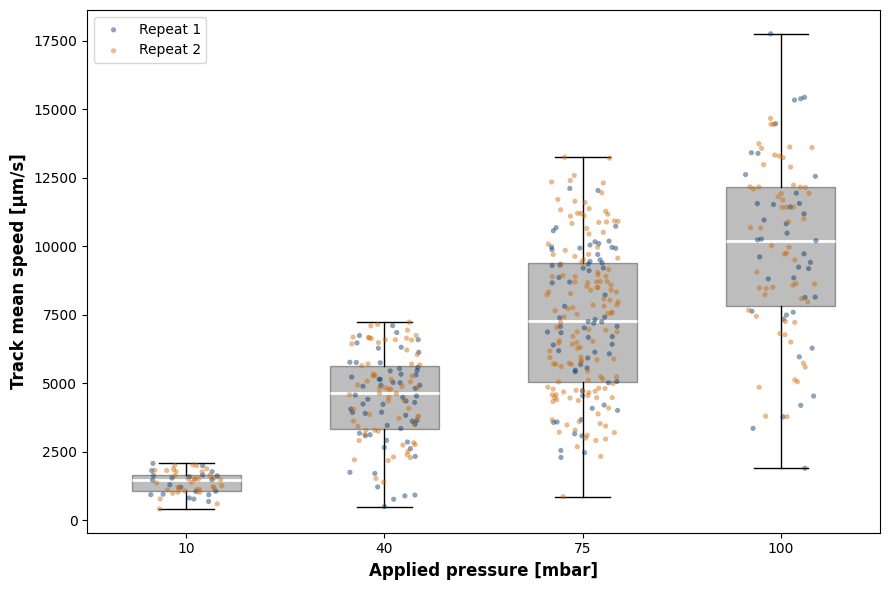

In [ ]:
# Merged boxplot: both repeats pooled per pressure, individual tracks shown as dots.
# Dots are coloured by repeat so per-repeat agreement is still visible.
fig, ax = plt.subplots(figsize=(9, 6))

pooled_by_pressure = [
    pd.concat([
        raw_1.loc[raw_1['Pressure_mbar'] == p, 'Track mean speed'].dropna(),
        raw_2.loc[raw_2['Pressure_mbar'] == p, 'Track mean speed'].dropna(),
    ]).values
    for p in CALIB_PRESSURES
]

bp = ax.boxplot(pooled_by_pressure, patch_artist=True,
                medianprops=dict(color='white', linewidth=2),
                showfliers=False, widths=0.55, zorder=2)
for patch in bp['boxes']:
    patch.set_facecolor('#444444')
    patch.set_alpha(0.35)

# Individual track dots, jittered, coloured by repeat
rng = np.random.default_rng(0)
for i, p in enumerate(CALIB_PRESSURES, start=1):
    for raw, color, label in [(raw_1, BLUE,   'Repeat 1'),
                              (raw_2, ORANGE, 'Repeat 2')]:
        d = raw.loc[raw['Pressure_mbar'] == p, 'Track mean speed'].dropna().values
        jitter = rng.uniform(-0.18, 0.18, size=len(d))
        ax.scatter(np.full_like(d, i, dtype=float) + jitter, d,
                   color=color, alpha=0.45, s=14, edgecolor='none', zorder=3,
                   label=label if i == 1 else None)

ax.set_xticks(range(1, len(CALIB_PRESSURES) + 1))
ax.set_xticklabels([f'{p}' for p in CALIB_PRESSURES], fontsize=11)
ax.set_xlabel('Applied pressure [mbar]', fontsize=12, fontweight='bold')
ax.set_ylabel('Track mean speed [μm/s]', fontsize=12, fontweight='bold')
ax.tick_params(labelsize=10)
ax.legend(fontsize=10, loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig('velocity_boxplots_unfiltered.pdf', bbox_inches='tight')
plt.show()


## 4 · Filter: retain fastest 25 % of tracks (P75)

The filtering is applied **independently per repeat and per pressure**,  
so each repeat's threshold adapts to its own distribution.  
The column used is `Track mean speed` (consistent with the calibration).

In [ ]:
def filter_top_quartile(df, speed_col='Track mean speed'):
    """Keep only tracks above the 75th percentile, computed per pressure."""
    def _filter(group):
        threshold = np.percentile(group[speed_col], 75)
        return group[group[speed_col] >= threshold]

    filtered = (df.groupby('Pressure_mbar', group_keys=False)
                  .apply(_filter, include_groups=True))
    return filtered.reset_index(drop=True)


fast_1 = filter_top_quartile(raw_1)
fast_2 = filter_top_quartile(raw_2)

print("Tracks retained after P75 filtering:")
print("  Repeat 1:", fast_1['Pressure_mbar'].value_counts().sort_index().to_dict())
print("  Repeat 2:", fast_2['Pressure_mbar'].value_counts().sort_index().to_dict())


Tracks retained after P75 filtering:
  Repeat 1: {10: 6, 40: 15, 75: 17, 100: 11}
  Repeat 2: {10: 9, 40: 17, 75: 36, 100: 15}


/tmp/ipykernel_8579/4153981552.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_filter, include_groups=True))
/tmp/ipykernel_8579/4153981552.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_filter, include_groups=True))


In [ ]:
# ── Track counts before and after P75 filtering ────────────────────────────
rows = []
for p in CALIB_PRESSURES:
    for rep_label, raw, fast in [("Repeat 1", raw_1, fast_1),
                                  ("Repeat 2", raw_2, fast_2)]:
        n_before = raw[raw['Pressure_mbar'] == p].shape[0]
        n_after  = fast[fast['Pressure_mbar'] == p].shape[0]
        rows.append({
            'Repeat':        rep_label,
            'Pressure (mbar)': int(p),
            'Tracks (all)':  n_before,
            'Tracks (P75)':  n_after,
            'Removed (%)':   f"{(1 - n_after / n_before) * 100:.0f}%",
        })

counts_df = pd.DataFrame(rows)

# Pivot for a compact display: pressures as columns
pivot = counts_df.pivot_table(
    index='Repeat',
    columns='Pressure (mbar)',
    values=['Tracks (all)', 'Tracks (P75)'],
    aggfunc='first'
)

# Flatten multi-index columns to "all / P75" per pressure
pivot.columns = [f'{p} mbar\n{stat.split()[1]}' for stat, p in pivot.columns]
print("Track counts before (all) and after (P75) filtering:\n")
print(counts_df.to_string(index=False))


Track counts before (all) and after (P75) filtering:

  Repeat  Pressure (mbar)  Tracks (all)  Tracks (P75) Removed (%)
Repeat 1               10            21             6         71%
Repeat 2               10            34             9         74%
Repeat 1               40            59            15         75%
Repeat 2               40            66            17         74%
Repeat 1               75            67            17         75%
Repeat 2               75           141            36         74%
Repeat 1              100            41            11         73%
Repeat 2              100            58            15         74%


## 5 · Compare technical repeats

Before combining, we verify that the two repeats yield equivalent results.

In [ ]:
def repeat_means(fast_df, speed_col='Track mean speed'):
    """Return per-pressure mean and SD of the filtered tracks."""
    return (fast_df.groupby('Pressure_mbar')[speed_col]
                   .agg(mean='mean', std='std', n='count')
                   .assign(sem=lambda x: x['std'] / np.sqrt(x['n'])))

stats_1 = repeat_means(fast_1)
stats_2 = repeat_means(fast_2)

print("Repeat 1 – filtered means (μm/s):")
print(stats_1[['mean', 'std', 'n']], "\n")
print("Repeat 2 – filtered means (μm/s):")
print(stats_2[['mean', 'std', 'n']])


Repeat 1 – filtered means (μm/s):
                       mean          std   n
Pressure_mbar                               
10              1822.073205   179.264227   6
40              6121.639665   547.887323  15
75             10294.365045   759.701874  17
100            13992.586947  1871.534036  11 

Repeat 2 – filtered means (μm/s):
                       mean          std   n
Pressure_mbar                               
10              1882.591905   101.036848   9
40              6672.047772   306.984204  17
75             10991.723945  1061.048455  36
100            13364.263118   799.116046  15


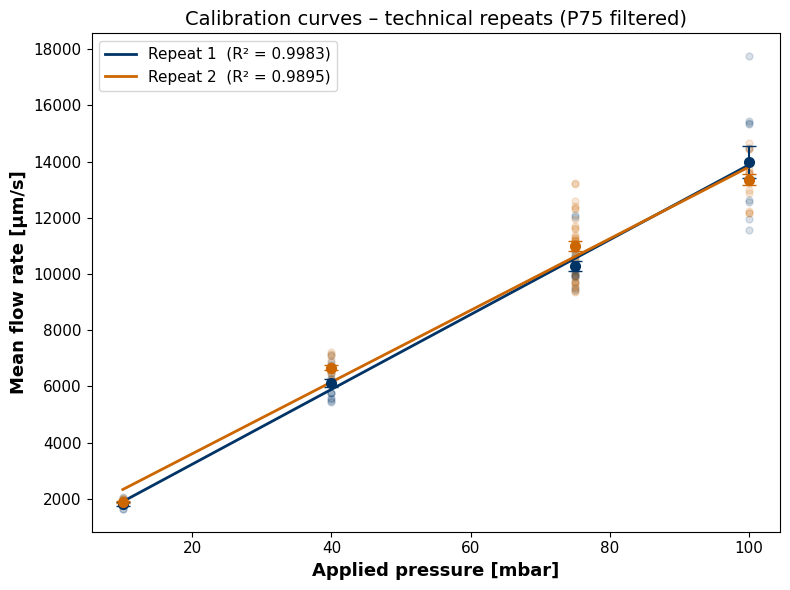

In [ ]:
# ── Side-by-side calibration lines per repeat ──────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for stats, fast, color, label in [
        (stats_1, fast_1, BLUE,   "Repeat 1"),
        (stats_2, fast_2, ORANGE, "Repeat 2")]:

    ax.scatter(fast['Pressure_mbar'], fast['Track mean speed'],
               color=color, alpha=0.15, s=25)

    ax.errorbar(stats.index, stats['mean'], yerr=stats['sem'],
                fmt='o', color=color, capsize=5, markersize=7)

    X = stats.index.values.reshape(-1, 1)
    m = LinearRegression().fit(X, stats['mean'].values)
    xfit = np.linspace(stats.index.min(), stats.index.max(), 100)
    ax.plot(xfit, m.predict(xfit.reshape(-1, 1)),
            color=color, linewidth=2,
            label=f'{label}  (R² = {m.score(X, stats["mean"].values):.4f})')

ax.set_xlabel('Applied pressure [mbar]', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean flow rate [μm/s]', fontsize=13, fontweight='bold')
ax.set_title('Calibration curves – technical repeats (P75 filtered)', fontsize=14)
ax.tick_params(labelsize=11)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('calibration_repeats_ums.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# ── Statistical comparison of the two repeats ──────────────────────────────
comparison = pd.DataFrame({
    'Pressure_mbar': stats_1.index,
    'Repeat_1':      stats_1['mean'].values,
    'Repeat_2':      stats_2.loc[stats_1.index, 'mean'].values,
})
comparison['Difference'] = comparison['Repeat_1'] - comparison['Repeat_2']

print(comparison.to_string(index=False))

# Wilcoxon signed-rank test (non-parametric, appropriate for n=4 pairs)
stat_w, p_w = wilcoxon(comparison['Repeat_1'], comparison['Repeat_2'])
# Paired t-test for completeness
stat_t, p_t = ttest_rel(comparison['Repeat_1'], comparison['Repeat_2'])

print(f"\nWilcoxon signed-rank:  W = {stat_w:.3f},  p = {p_w:.4f}")
print(f"Paired t-test:          t = {stat_t:.3f},  p = {p_t:.4f}")


 Pressure_mbar     Repeat_1     Repeat_2  Difference
            10  1822.073205  1882.591905  -60.518700
            40  6121.639665  6672.047772 -550.408107
            75 10294.365045 10991.723945 -697.358900
           100 13992.586947 13364.263118  628.323830

Wilcoxon signed-rank:  W = 3.000,  p = 0.6250
Paired t-test:          t = -0.569,  p = 0.6093


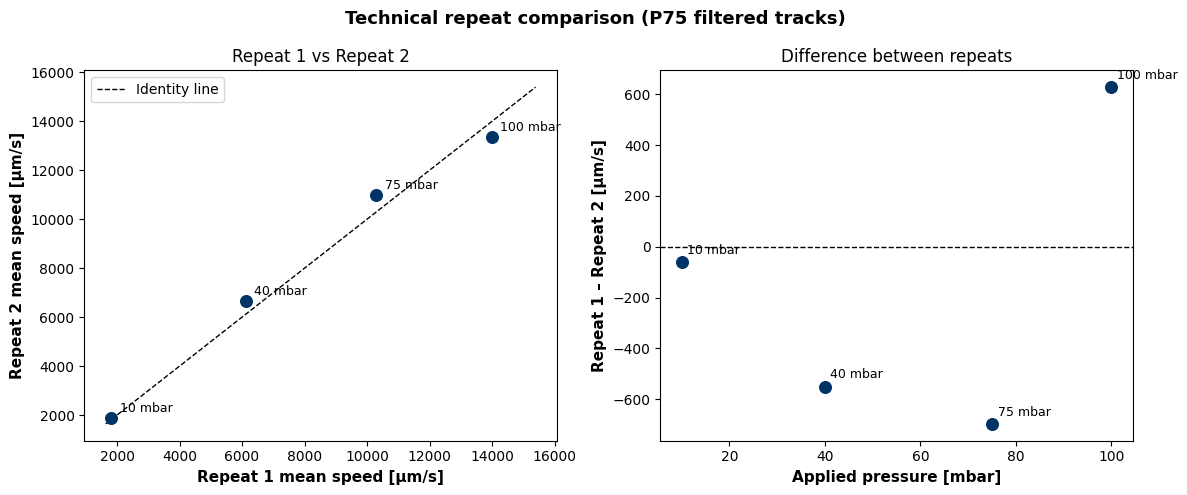

In [ ]:
# ── Bland–Altman-style difference plot ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: scatter repeat 1 vs repeat 2
ax = axes[0]
lims = [comparison[['Repeat_1','Repeat_2']].min().min() * 0.9,
        comparison[['Repeat_1','Repeat_2']].max().max() * 1.1]
ax.plot(lims, lims, 'k--', linewidth=1, label='Identity line')
ax.scatter(comparison['Repeat_1'], comparison['Repeat_2'],
           s=70, color=BLUE, zorder=3)
for _, row in comparison.iterrows():
    ax.annotate(f"{int(row['Pressure_mbar'])} mbar",
                (row['Repeat_1'], row['Repeat_2']),
                textcoords='offset points', xytext=(6, 4), fontsize=9)
ax.set_xlabel('Repeat 1 mean speed [μm/s]', fontsize=11, fontweight='bold')
ax.set_ylabel('Repeat 2 mean speed [μm/s]', fontsize=11, fontweight='bold')
ax.set_title('Repeat 1 vs Repeat 2', fontsize=12)
ax.legend(fontsize=10)

# Right: difference vs pressure
ax = axes[1]
ax.axhline(0, color='k', linestyle='--', linewidth=1)
ax.scatter(comparison['Pressure_mbar'], comparison['Difference'],
           s=70, color=BLUE, zorder=3)
for _, row in comparison.iterrows():
    ax.annotate(f"{int(row['Pressure_mbar'])} mbar",
                (row['Pressure_mbar'], row['Difference']),
                textcoords='offset points', xytext=(4, 6), fontsize=9)
ax.set_xlabel('Applied pressure [mbar]', fontsize=11, fontweight='bold')
ax.set_ylabel('Repeat 1 – Repeat 2 [μm/s]', fontsize=11, fontweight='bold')
ax.set_title('Difference between repeats', fontsize=12)

plt.suptitle('Technical repeat comparison (P75 filtered tracks)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('repeat_comparison.pdf', bbox_inches='tight')
plt.show()


**Interpretation:** No statistically significant difference was found between the two technical repeats  
(Wilcoxon signed-rank test; paired t-test – see printed p-values above),  
indicating good reproducibility. The two repeats are therefore combined in Section 6.

## 6 · Combine technical repeats

The two per-repeat means are averaged to give the combined estimate.  
Uncertainty is reported as the standard deviation between tracks (n = 126),  
which reflects inter-repeat variability rather than within-repeat track dispersion.

In [ ]:
combined_means = pd.DataFrame({
    'Pressure_mbar': stats_1.index,
    'Rep1_mean':     stats_1['mean'].values,
    'Rep2_mean':     stats_2.loc[stats_1.index, 'mean'].values,
})

combined_means['Mean_combined'] = combined_means[['Rep1_mean', 'Rep2_mean']].mean(axis=1)

# SD across ALL individual filtered tracks pooled from both repeats (per pressure),
# and total track count -- used as error bars and reported as n in the calibration plot.
pooled_tracks = pd.concat([fast_1, fast_2], ignore_index=True)
pooled_stats  = (pooled_tracks.groupby('Pressure_mbar')['Track mean speed']
                              .agg(SD_pooled='std', n_total='count'))
combined_means = combined_means.merge(
    pooled_stats, left_on='Pressure_mbar', right_index=True)

# Per-repeat track counts (informational; N = 2 always)
n1 = fast_1.groupby('Pressure_mbar').size().rename('n_rep1')
n2 = fast_2.groupby('Pressure_mbar').size().rename('n_rep2')
combined_means = combined_means.merge(n1, left_on='Pressure_mbar', right_index=True)
combined_means = combined_means.merge(n2, left_on='Pressure_mbar', right_index=True)

# Kept for backward compatibility / reference (SD between the two per-repeat means)
combined_means['SD_between'] = (
    pd.DataFrame({'a': combined_means['Rep1_mean'],
                  'b': combined_means['Rep2_mean']})
    .std(axis=1, ddof=1)
)

print(combined_means[['Pressure_mbar', 'Rep1_mean', 'Rep2_mean',
                      'Mean_combined', 'SD_pooled',
                      'n_rep1', 'n_rep2', 'n_total']].to_string(index=False))


 Pressure_mbar    Rep1_mean    Rep2_mean  Mean_combined   SD_pooled  n_rep1  n_rep2  n_total
            10  1822.073205  1882.591905    1852.332555  135.100735       6       9       15
            40  6121.639665  6672.047772    6396.843719  511.937547      15      17       32
            75 10294.365045 10991.723945   10643.044495 1021.440183      17      36       53
           100 13992.586947 13364.263118   13678.425032 1363.407646      11      15       26


## 7 · Calibration curve in μm/s

In [ ]:
X_comb = combined_means['Pressure_mbar'].values.reshape(-1, 1)
y_comb = combined_means['Mean_combined'].values

model_ums = LinearRegression().fit(X_comb, y_comb)
slope_ums     = model_ums.coef_[0]
intercept_ums = model_ums.intercept_
r2_ums        = model_ums.score(X_comb, y_comb)

print(f"Calibration (μm/s):  v = {slope_ums:.4f} · P + {intercept_ums:.4f}")
print(f"R² = {r2_ums:.4f}")


Calibration (μm/s):  v = 130.3066 · P + 812.9134
R² = 0.9970


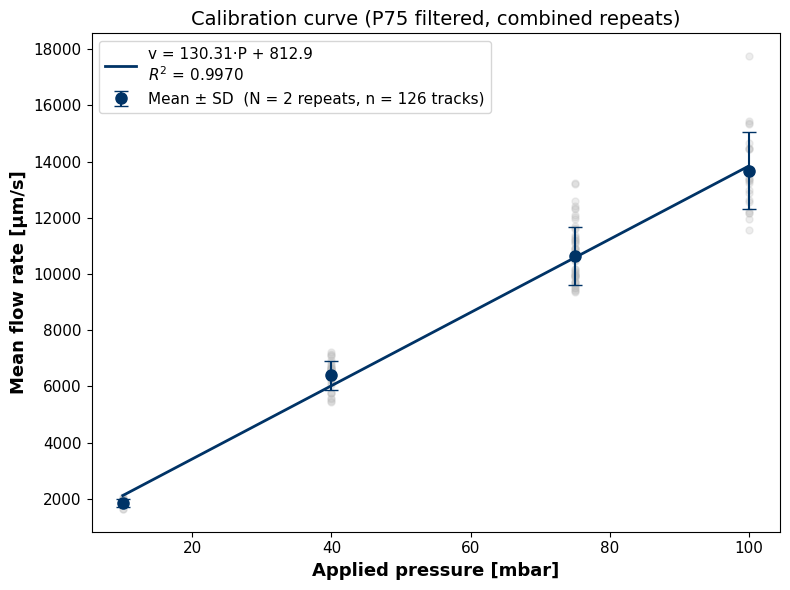

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# Individual filtered tracks (both repeats, same grey)
for fast in [fast_1, fast_2]:
    ax.scatter(fast['Pressure_mbar'], fast['Track mean speed'],
               color=GRAY, alpha=0.25, s=25, zorder=1)

# Combined mean ± SD across all individual tracks (per pressure)
n_total_all = int(combined_means['n_total'].sum())
ax.errorbar(combined_means['Pressure_mbar'], combined_means['Mean_combined'],
            yerr=combined_means['SD_pooled'],
            fmt='o', color=BLUE, capsize=5, markersize=8, zorder=3,
            label=f'Mean ± SD  (N = 2 repeats, n = {n_total_all} tracks)')

# Fit line
xfit = np.linspace(combined_means['Pressure_mbar'].min(),
                   combined_means['Pressure_mbar'].max(), 100)
ax.plot(xfit, model_ums.predict(xfit.reshape(-1, 1)),
        color=BLUE, linewidth=2,
        label=f'v = {slope_ums:.2f}·P + {intercept_ums:.1f}\n$R^2$ = {r2_ums:.4f}')

ax.set_xlabel('Applied pressure [mbar]', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean flow rate [μm/s]',   fontsize=13, fontweight='bold')
ax.set_title('Calibration curve (P75 filtered, combined repeats)', fontsize=14)
ax.tick_params(labelsize=11)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('calibration_curve_ums.pdf', bbox_inches='tight')
plt.show()


## 8 · Convert to volumetric flow rate (μL/h) and final calibration curve

The mean velocity $\bar{v}$ is converted to volumetric flow rate $Q$ using the channel cross-section:

$$Q = \bar{v} \times A$$

Channel geometry: width $w = 50\,\mu$m, height $h = 20\,\mu$m  
$A = w \times h = 1000\,\mu$m² $= 10^{-3}\,\mu$m$\cdot$s$^{-1}$ → μL/h conversion factor = 0.0036

$$1\,\frac{\mu\text{m}}{\text{s}} \times 1000\,\mu\text{m}^2 = 10^3\,\frac{\mu\text{m}^3}{\text{s}} = 10^{-9}\,\frac{\text{mL}}{\text{s}} = 3.6\times10^{-3}\,\frac{\mu\text{L}}{\text{h}}$$

In [ ]:
# ── Conversion ─────────────────────────────────────────────────────────────
CONVERSION = 0.0036   # (μm/s) → (μL/h),  for A = 1000 μm²

combined_means['Mean_uLh'] = combined_means['Mean_combined'] * CONVERSION
combined_means['SD_uLh']   = combined_means['SD_pooled']     * CONVERSION

print(combined_means[['Pressure_mbar', 'Mean_uLh', 'SD_uLh', 'n_total']].to_string(index=False))


 Pressure_mbar  Mean_uLh   SD_uLh  n_total
            10  6.668397 0.486363       15
            40 23.028637 1.842975       32
            75 38.314960 3.677185       53
           100 49.242330 4.908268       26


In [ ]:
X_final = combined_means['Pressure_mbar'].values.reshape(-1, 1)
y_final = combined_means['Mean_uLh'].values

model_final   = LinearRegression().fit(X_final, y_final)
slope_final     = model_final.coef_[0]
intercept_final = model_final.intercept_
r2_final        = model_final.score(X_final, y_final)

print(f"Final calibration (μL/h):  Q = {slope_final:.4f} · P + {intercept_final:.4f}")
print(f"R² = {r2_final:.4f}")


Final calibration (μL/h):  Q = 0.4691 · P + 2.9265
R² = 0.9970


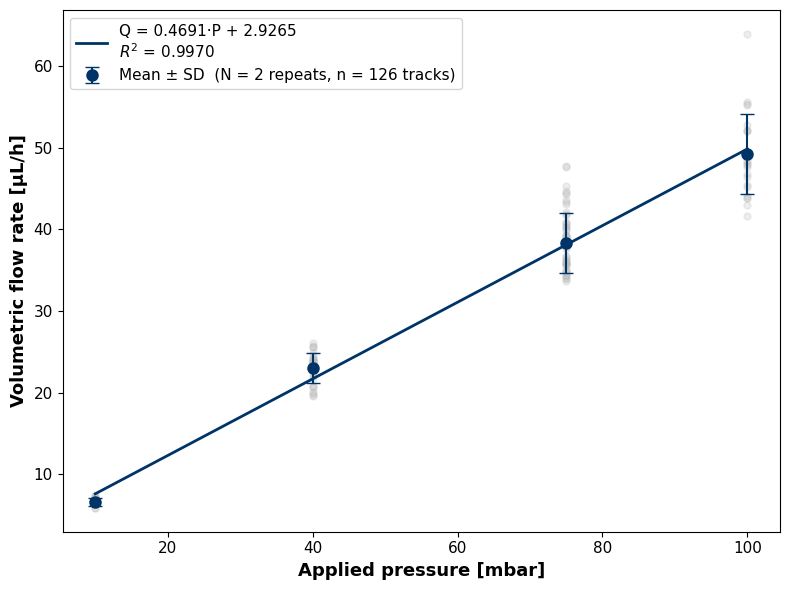


Final equation:  Q [μL/h] = 0.4691 · P [mbar] + 2.9265


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# Individual filtered tracks converted to μL/h
for fast in [fast_1, fast_2]:
    ax.scatter(fast['Pressure_mbar'],
               fast['Track mean speed'] * CONVERSION,
               color=GRAY, alpha=0.25, s=25, zorder=1)

# Combined mean ± SD across all individual tracks (per pressure)
n_total_all = int(combined_means['n_total'].sum())
ax.errorbar(combined_means['Pressure_mbar'], combined_means['Mean_uLh'],
            yerr=combined_means['SD_uLh'],
            fmt='o', color=BLUE, capsize=5, markersize=8, zorder=3,
            label=f'Mean ± SD  (N = 2 repeats, n = {n_total_all} tracks)')

# Fit line
xfit = np.linspace(combined_means['Pressure_mbar'].min(),
                   combined_means['Pressure_mbar'].max(), 100)
ax.plot(xfit, model_final.predict(xfit.reshape(-1, 1)),
        color=BLUE, linewidth=2,
        label=f'Q = {slope_final:.4f}·P + {intercept_final:.4f}\n$R^2$ = {r2_final:.4f}')

ax.set_xlabel('Applied pressure [mbar]', fontsize=13, fontweight='bold')
ax.set_ylabel('Volumetric flow rate [μL/h]', fontsize=13, fontweight='bold')
#ax.set_title('Pressure–flow rate calibration curve', fontsize=14)
ax.tick_params(labelsize=11)
ax.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.savefig('calibration_curve_uLh.pdf', bbox_inches='tight')
plt.show()

print(f"\nFinal equation:  Q [μL/h] = {slope_final:.4f} · P [mbar] + {intercept_final:.4f}")


## Summary

| Step | Details |
|------|---------|
| Raw data | TrackMate trajectories at 10, 40, 75, 100 mbar (two technical repeats) |
| Velocity metric | Track mean speed [μm/s] |
| Filtering | Top 25 % per pressure per repeat (P75 threshold) |
| Justification | TrackMate residual slow-track detection bias; P75 retains upper-quartile as best estimate of bulk flow |
| Repeat comparison | No significant difference (Wilcoxon & paired t-test) |
| Combining | Mean of two per-repeat means (each repeat weighted equally) |
| Uncertainty | SD across **all individual filtered tracks pooled from both repeats**, per pressure. N = 2 technical repeats, n = total number of individual tracks |
| Unit conversion | × 0.0036 (channel area = 1000 μm²) |
| Final curve | Linear fit Q [μL/h] = slope · P [mbar] + intercept |
